# 08 - Behavioral Predictor (Low-Level Walkthrough)

This notebook rebuilds the simplified hybrid behavioral predictor step-by-step.

- No helper functions wrapping the core logic.
- One transformation per cell.
- Every key intermediate object is displayed.
- Graphs are used to illustrate learned distributions and predictions.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aerogrid.behavioral_predictor import load_onsets
from aerogrid.config import SLOT_MINUTES, SLOTS_PER_DAY

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
plt.style.use("seaborn-v0_8-whitegrid")

## 1) Load and inspect raw onset data

Expected columns:
- `timestamp` (tz-aware datetime)
- `appliance` (string)
- `split` (`train` / `test`)

In [22]:
onsets = load_onsets()
print(onsets.shape)
onsets.head()

(418, 3)


,timestamp,appliance,split
0,2026-01-12 00:00:00+00:00,fridge,train
1,2026-01-12 19:00:00+00:00,ev_charger,train
2,2026-01-12 20:34:00+00:00,dishwasher,train
3,2026-01-13 04:48:00+00:00,heater,train
4,2026-01-13 09:20:00+00:00,washing_machine,train


## 2) Keep the training split and add explicit feature columns

We derive `date`, `slot`, and `is_weekend` directly from `timestamp`.

In [23]:
onsets["timestamp"] = pd.to_datetime(onsets["timestamp"], utc=True, errors="coerce")
train = onsets[onsets["split"] == "train"].copy()

# Defensive coercion so reruns remain stable even if upstream cells changed dtypes.
train["timestamp"] = pd.to_datetime(train["timestamp"], utc=True, errors="coerce")
train = train.dropna(subset=["timestamp"]).copy()

train["date"] = train["timestamp"].dt.floor("D")
train["slot"] = ((train["timestamp"].dt.hour * 60 + train["timestamp"].dt.minute) // SLOT_MINUTES).astype(int)
train["is_weekend"] = train["timestamp"].dt.dayofweek >= 5

print(train.shape)
train.head()

(349, 6)


,timestamp,appliance,split,date,slot,is_weekend
0,2026-01-12 00:00:00+00:00,fridge,train,2026-01-12 00:00:00+00:00,0,False
1,2026-01-12 19:00:00+00:00,ev_charger,train,2026-01-12 00:00:00+00:00,76,False
2,2026-01-12 20:34:00+00:00,dishwasher,train,2026-01-12 00:00:00+00:00,82,False
3,2026-01-13 04:48:00+00:00,heater,train,2026-01-13 00:00:00+00:00,19,False
4,2026-01-13 09:20:00+00:00,washing_machine,train,2026-01-13 00:00:00+00:00,37,False


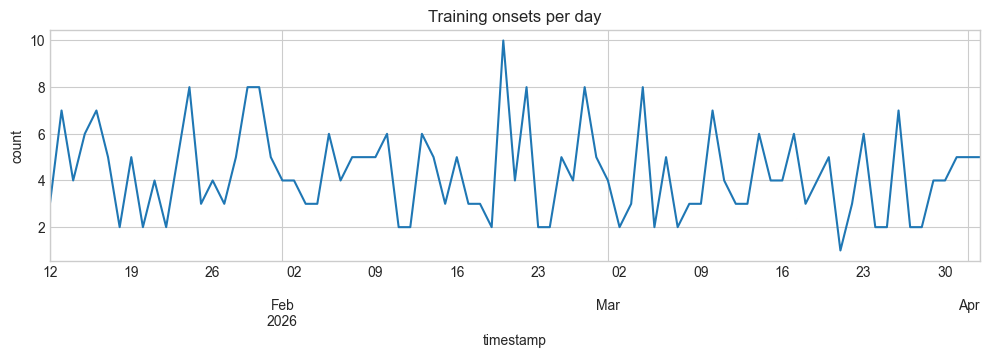

In [24]:
fig, ax = plt.subplots(figsize=(12, 3))
(
    train.groupby(pd.Grouper(key="timestamp", freq="D"))
    .size()
    .rename("onsets")
    .plot(ax=ax)
)
ax.set_title("Training onsets per day")
ax.set_ylabel("count")
plt.show()

## 3) Compute calendar-day denominators

The model normalizes event counts by the number of days in the train span.

In [25]:
dates = pd.DataFrame({
    "date": pd.date_range(train["date"].min(), train["date"].max(), freq="D")
})
dates["is_weekend"] = dates["date"].dt.dayofweek >= 5

n_days_total = len(dates)
n_days_weekend = int(dates["is_weekend"].sum())
n_days_weekday = n_days_total - n_days_weekend

print({
    "n_days_total": n_days_total,
    "n_days_weekend": n_days_weekend,
    "n_days_weekday": n_days_weekday,
})
dates.head()

{'n_days_total': 81, 'n_days_weekend': 22, 'n_days_weekday': 59}


,date,is_weekend
0,2026-01-12 00:00:00+00:00,False
1,2026-01-13 00:00:00+00:00,False
2,2026-01-14 00:00:00+00:00,False
3,2026-01-15 00:00:00+00:00,False
4,2026-01-16 00:00:00+00:00,False


## 4) Daily onset counts per appliance, then `daily_rate`

`daily_rate` = total onsets for appliance / total days in train span.

In [26]:
per_day = (
    train.groupby(["appliance", "date"], observed=True)
    .size()
    .rename("onsets")
    .reset_index()
)

daily_rate = (
    per_day.groupby("appliance", observed=True)["onsets"]
    .sum()
    .div(max(1, n_days_total))
    .rename("daily_rate")
    .sort_values(ascending=False)
)

display(per_day.head())
display(daily_rate.to_frame().head(10))

,appliance,date,onsets
0,dishwasher,2026-01-12 00:00:00+00:00,1
1,dishwasher,2026-01-13 00:00:00+00:00,1
2,dishwasher,2026-01-14 00:00:00+00:00,2
3,dishwasher,2026-01-15 00:00:00+00:00,3
4,dishwasher,2026-01-16 00:00:00+00:00,2


,daily_rate
appliance,
heater,1.592593
ev_charger,1.000000
washing_machine,0.950617
dishwasher,0.753086
fridge,0.012346


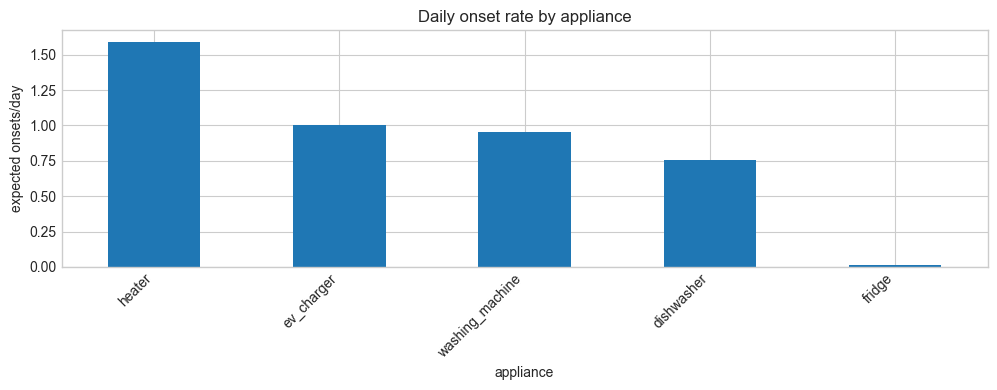

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
daily_rate.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Daily onset rate by appliance")
ax.set_ylabel("expected onsets/day")
ax.set_xlabel("appliance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5) Weekend multiplier per appliance

`weekend_mult = weekend_daily_rate / daily_rate`

- > 1: more starts on weekends
- < 1: fewer starts on weekends

In [28]:
per_day_w = per_day.copy()
per_day_w["date"] = pd.to_datetime(per_day_w["date"], utc=True, errors="coerce")
per_day_w = per_day_w.dropna(subset=["date"]).copy()
per_day_w["is_weekend"] = per_day_w["date"].dt.dayofweek >= 5

weekend_day_counts = (
    per_day_w.groupby(["appliance", "is_weekend"], observed=True)["onsets"]
    .sum()
    .unstack(fill_value=0)
    .astype(float)
)

# Mean weekend onsets/day by appliance.
# .get(True, fallback) means: use weekend column if present; otherwise use zeros.
weekend_daily_rate = weekend_day_counts.get(True, pd.Series(0.0, index=weekend_day_counts.index)) / max(1, n_days_weekend)

# Weekend multiplier relative to overall daily activity.
# Replace divide-by-zero infinities/NaN with 1.0 so missing data stays neutral.
weekend_mult = (weekend_daily_rate / daily_rate).replace([np.inf, -np.inf], np.nan).fillna(1.0).rename("weekend_mult")

display(weekend_day_counts.head())
display(weekend_mult.sort_values(ascending=False).to_frame().head(10))

is_weekend,False,True
appliance,,
dishwasher,47.0,14.0
ev_charger,59.0,22.0
fridge,1.0,0.0
heater,95.0,34.0
washing_machine,56.0,21.0


,weekend_mult
appliance,
washing_machine,1.004132
ev_charger,1.000000
heater,0.970402
dishwasher,0.845007
fridge,0.000000


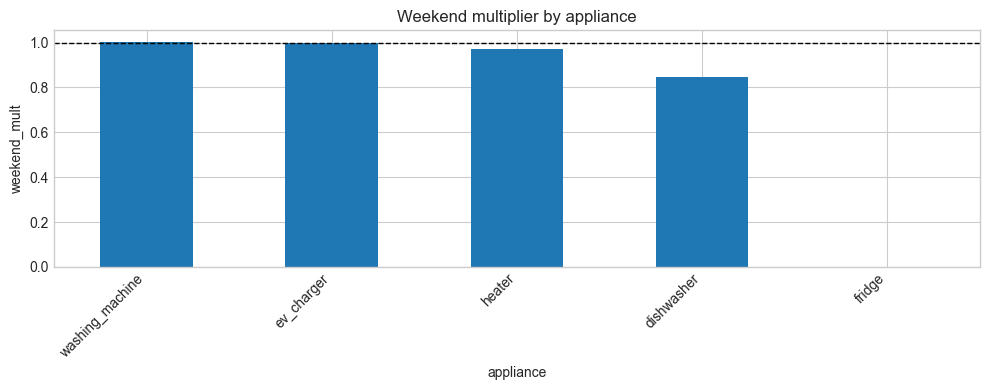

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
weekend_mult.sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Weekend multiplier by appliance")
ax.set_ylabel("weekend_mult")
ax.set_xlabel("appliance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6) Learn per-appliance 96-slot shape from histograms

We build raw slot counts, apply circular moving-average smoothing, then normalize to a PMF.

In [30]:
min_onsets_for_profile = 3
appliances = sorted(train["appliance"].astype(str).unique().tolist())

train_counts = train.groupby("appliance", observed=True).size()
appliances = [a for a in appliances if int(train_counts.get(a, 0)) >= min_onsets_for_profile]
appliances = sorted(appliances)
slot_index = np.arange(SLOTS_PER_DAY)
smoothing_window = 5

slot_counts_table = (
    train.groupby(["appliance", "slot"], observed=True)
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="appliance", columns="slot", values="count")
    .reindex(index=appliances, columns=slot_index)
    .fillna(0.0)
)

raw_counts = slot_counts_table.to_numpy(dtype=np.float64)

pad = smoothing_window // 2
wrapped = np.pad(raw_counts, ((0, 0), (pad, pad)), mode="wrap")
kernel = np.ones(smoothing_window, dtype=np.float64) / smoothing_window
smoothed = np.vstack([np.convolve(row, kernel, mode="valid")[:SLOTS_PER_DAY] for row in wrapped])

slot_pmf = smoothed / (smoothed.sum(axis=1, keepdims=True) + 1e-12)
slot_pmf_df = pd.DataFrame(slot_pmf, index=appliances, columns=slot_index)

display(slot_counts_table.head())
display(slot_pmf_df.iloc[:5, :12])

slot,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
appliance,,,,,,,,,,,,,,,,,,,,,
dishwasher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ev_charger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heater,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
washing_machine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,0,1,2,3,4,5,6,7,8,9,10,11
dishwasher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ev_charger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heater,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
washing_machine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# Fix-up: pivot can leave NaNs for unseen appliance/slot combinations.
# Fill missing counts with zero, then recompute PMF safely.
slot_counts_table = slot_counts_table.fillna(0.0)
raw_counts = slot_counts_table.to_numpy(dtype=np.float64)

pad = smoothing_window // 2
wrapped = np.pad(raw_counts, ((0, 0), (pad, pad)), mode="wrap")
kernel = np.ones(smoothing_window, dtype=np.float64) / smoothing_window
smoothed = np.vstack([np.convolve(row, kernel, mode="valid")[:SLOTS_PER_DAY] for row in wrapped])

slot_pmf = smoothed / (smoothed.sum(axis=1, keepdims=True) + 1e-12)
slot_pmf_df = pd.DataFrame(slot_pmf, index=appliances, columns=slot_index)

display(slot_counts_table.head())
display(slot_pmf_df.iloc[:5, :12])
print("Any NaNs in slot_pmf_df:", bool(slot_pmf_df.isna().any().any()))

slot,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
appliance,,,,,,,,,,,,,,,,,,,,,
dishwasher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ev_charger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heater,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
washing_machine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,0,1,2,3,4,5,6,7,8,9,10,11
dishwasher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ev_charger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heater,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
washing_machine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Any NaNs in slot_pmf_df: False


## 6b) Sparsity diagnostics + heatmaps

This section quantifies how sparse the 96-slot tables are and visualizes them with heatmaps.

In [32]:
# Global sparsity metrics for raw slot counts.
slot_counts_arr = slot_counts_table.to_numpy(dtype=float)
zero_mask = slot_counts_arr == 0.0

n_cells = zero_mask.size
n_zeros = int(zero_mask.sum())
zero_ratio = n_zeros / n_cells if n_cells else np.nan

sparsity_summary = pd.DataFrame({
    "n_rows_appliances": [slot_counts_table.shape[0]],
    "n_cols_slots": [slot_counts_table.shape[1]],
    "n_cells": [n_cells],
    "n_zero_cells": [n_zeros],
    "zero_ratio": [zero_ratio],
    "non_zero_ratio": [1.0 - zero_ratio],
})

display(sparsity_summary)

# Per-appliance sparsity.
per_appliance_sparsity = pd.DataFrame({
    "nonzero_slots": (slot_counts_table > 0).sum(axis=1),
    "zero_slots": (slot_counts_table == 0).sum(axis=1),
    "total_onsets": slot_counts_table.sum(axis=1),
})
per_appliance_sparsity["zero_ratio"] = per_appliance_sparsity["zero_slots"] / SLOTS_PER_DAY

display(per_appliance_sparsity.sort_values("zero_ratio", ascending=False))

,n_rows_appliances,n_cols_slots,n_cells,n_zero_cells,zero_ratio,non_zero_ratio
0,4,96,384,332,0.864583,0.135417


,nonzero_slots,zero_slots,total_onsets,zero_ratio
appliance,,,,
ev_charger,1,95,81.0,0.989583
dishwasher,11,85,61.0,0.885417
washing_machine,18,78,77.0,0.812500
heater,22,74,129.0,0.770833


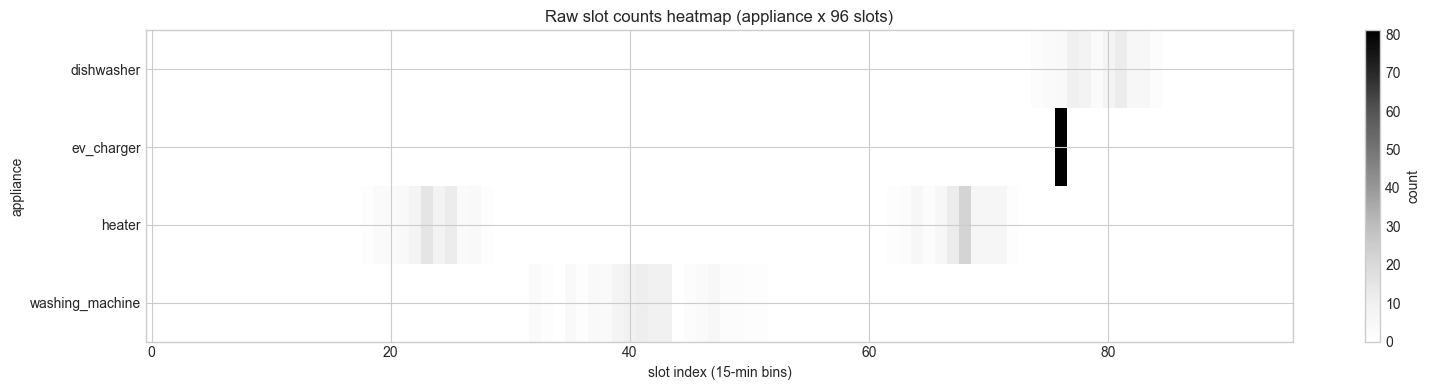

In [33]:
# Heatmap 1: raw slot counts (sparse by construction).
fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(slot_counts_table.to_numpy(dtype=float), aspect="auto", interpolation="nearest")

ax.set_title("Raw slot counts heatmap (appliance x 96 slots)")
ax.set_xlabel("slot index (15-min bins)")
ax.set_ylabel("appliance")
ax.set_yticks(np.arange(len(slot_counts_table.index)))
ax.set_yticklabels(slot_counts_table.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("count")
plt.tight_layout()
plt.show()

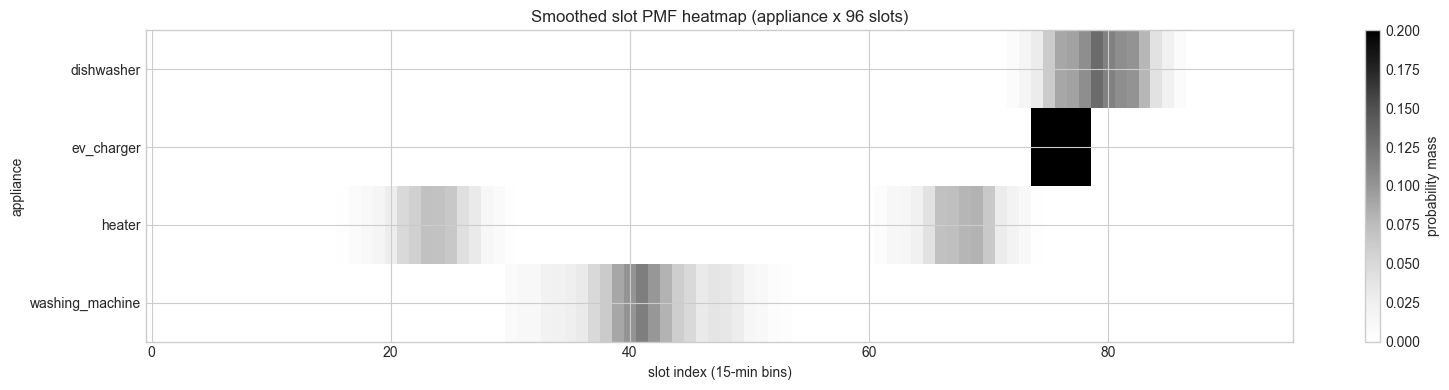

In [34]:
# Heatmap 2: learned PMF (after smoothing + normalization).
fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(slot_pmf_df.to_numpy(dtype=float), aspect="auto", interpolation="nearest")

ax.set_title("Smoothed slot PMF heatmap (appliance x 96 slots)")
ax.set_xlabel("slot index (15-min bins)")
ax.set_ylabel("appliance")
ax.set_yticks(np.arange(len(slot_pmf_df.index)))
ax.set_yticklabels(slot_pmf_df.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("probability mass")
plt.tight_layout()
plt.show()

Active slots: 51 out of 96


slot,18,19,20,21,22,23,24,25,26,27,...,75,76,77,78,79,80,81,82,83,84
appliance,,,,,,,,,,,,,,,,,,,,,
dishwasher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,4.0,10.0,8.0,3.0,7.0,12.0,5.0,5.0,2.0
ev_charger,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,81.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heater,1.0,3.0,3.0,4.0,7.0,15.0,8.0,12.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
washing_machine,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


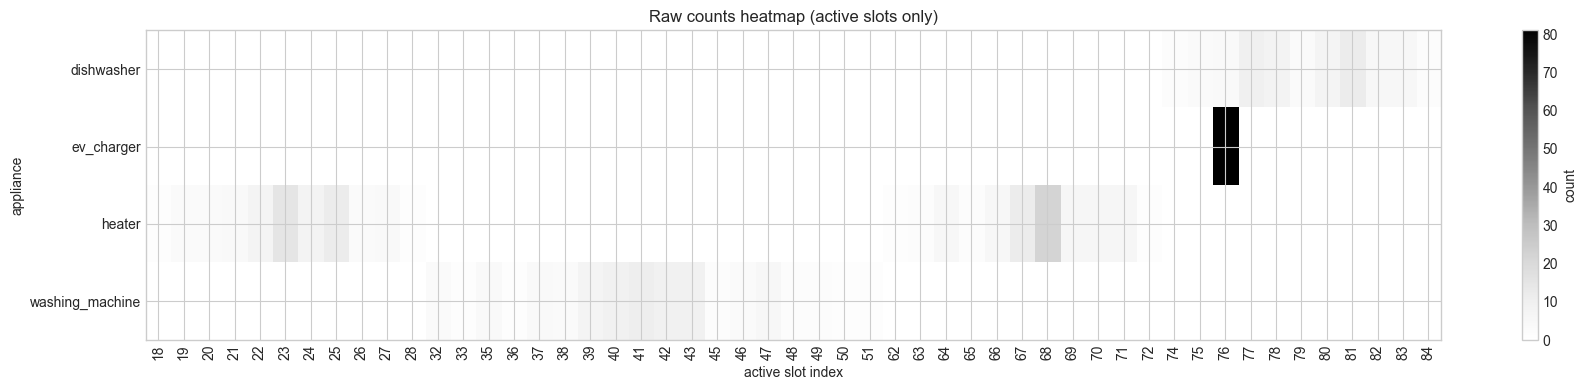

In [35]:
# Heatmap 3: only slots that have at least one onset somewhere.
active_slot_mask = (slot_counts_table > 0).any(axis=0)
slot_counts_active = slot_counts_table.loc[:, active_slot_mask]

print("Active slots:", int(active_slot_mask.sum()), "out of", SLOTS_PER_DAY)

display(slot_counts_active)

fig, ax = plt.subplots(figsize=(max(8, slot_counts_active.shape[1] * 0.35), 4))
im = ax.imshow(slot_counts_active.to_numpy(dtype=float), aspect="auto", interpolation="nearest")

ax.set_title("Raw counts heatmap (active slots only)")
ax.set_xlabel("active slot index")
ax.set_ylabel("appliance")
ax.set_xticks(np.arange(slot_counts_active.shape[1]))
ax.set_xticklabels(slot_counts_active.columns.astype(int), rotation=90)
ax.set_yticks(np.arange(len(slot_counts_active.index)))
ax.set_yticklabels(slot_counts_active.index)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("count")
plt.tight_layout()
plt.show()

## 7) Combine learned components into a parameter table

In [36]:
params = (
    pd.DataFrame({"appliance": appliances})
    .set_index("appliance")
    .join(daily_rate.rename("daily_rate"), how="left")
    .join(weekend_mult.rename("weekend_mult"), how="left")
    .fillna({"daily_rate": 0.0, "weekend_mult": 1.0})
)

params.head(10)

,daily_rate,weekend_mult
appliance,,
dishwasher,0.753086,0.845007
ev_charger,1.000000,1.000000
heater,1.592593,0.970402
washing_machine,0.950617,1.004132


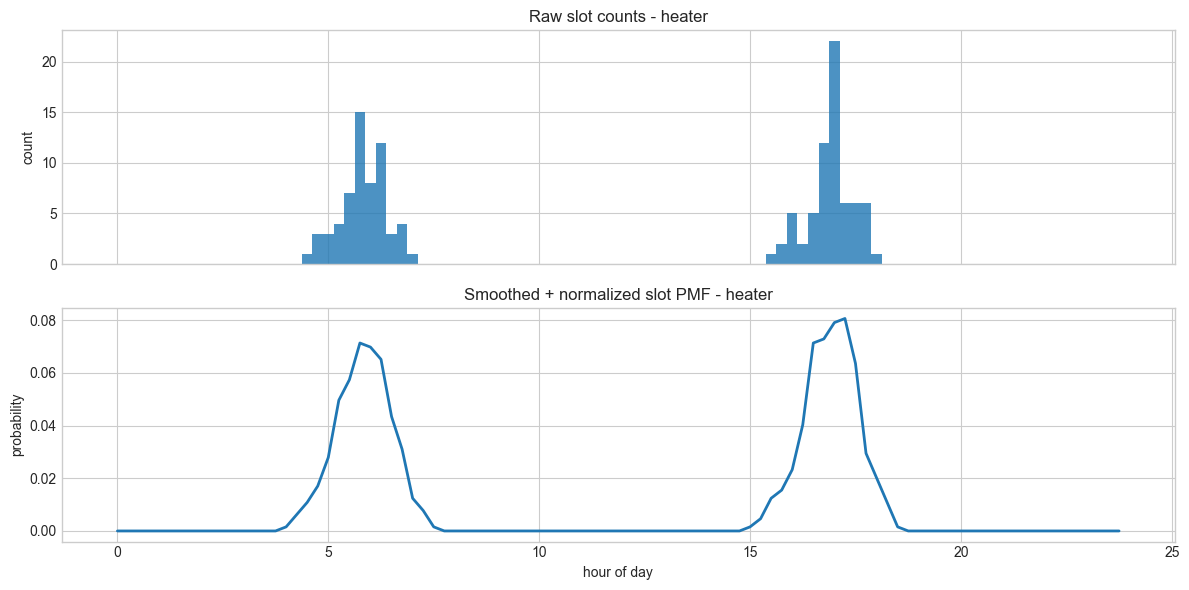

In [37]:
example_app = params["daily_rate"].sort_values(ascending=False).index[0]

x = np.arange(SLOTS_PER_DAY) * (SLOT_MINUTES / 60.0)
raw = slot_counts_table.loc[example_app].to_numpy(dtype=float)
pmf = slot_pmf_df.loc[example_app].to_numpy(dtype=float)

# Safety checks: if these fail, rerun the slot-count/PMF construction cell.
assert np.isfinite(raw).all(), "raw contains NaN/inf"
assert np.isfinite(pmf).all(), "pmf contains NaN/inf"
assert pmf.sum() > 0, "pmf sums to zero; rerun upstream cells"

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axs[0].bar(x, raw, width=SLOT_MINUTES / 60.0, alpha=0.8)
axs[0].set_title(f"Raw slot counts - {example_app}")
axs[0].set_ylabel("count")

axs[1].plot(x, pmf, linewidth=2)
axs[1].set_title(f"Smoothed + normalized slot PMF - {example_app}")
axs[1].set_ylabel("probability")
axs[1].set_xlabel("hour of day")

plt.tight_layout()
plt.show()

## 8) Low-level prediction example (no wrapper function)

We manually unroll the prediction logic for one appliance over one day horizon.

In [38]:
start_time = train["timestamp"].max().floor("15min")
horizon_slots = SLOTS_PER_DAY
appliance = example_app

slots = [((start_time + pd.Timedelta(minutes=SLOT_MINUTES * k)).hour * 60 + (start_time + pd.Timedelta(minutes=SLOT_MINUTES * k)).minute) // SLOT_MINUTES for k in range(horizon_slots)]
is_weekend_h = [(start_time + pd.Timedelta(minutes=SLOT_MINUTES * k)).weekday() >= 5 for k in range(horizon_slots)]

base_rate = params.loc[appliance, "daily_rate"]
we_mult = params.loc[appliance, "weekend_mult"]
shape = slot_pmf_df.loc[appliance].to_numpy()

pred = np.array([
    min(shape[slot] * base_rate * (we_mult if weekend else 1.0), 1.0)
    for slot, weekend in zip(slots, is_weekend_h)
], dtype=float)

pred[:12]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

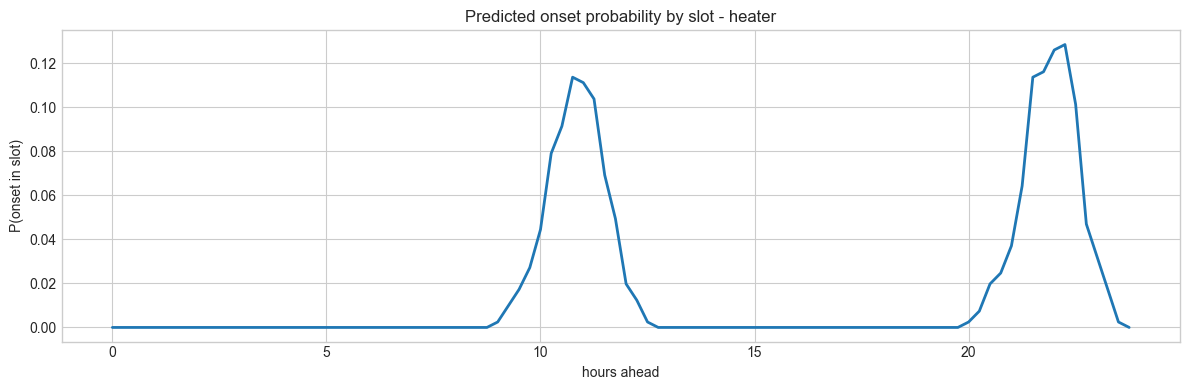

sum(pred) over 24h: 1.5925925925925801
daily_rate: 1.5925925925925926


In [39]:
hours = np.arange(horizon_slots) * (SLOT_MINUTES / 60.0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours, pred, linewidth=2)
ax.set_title(f"Predicted onset probability by slot - {appliance}")
ax.set_xlabel("hours ahead")
ax.set_ylabel("P(onset in slot)")
plt.tight_layout()
plt.show()

print("sum(pred) over 24h:", float(pred.sum()))
print("daily_rate:", float(base_rate))

## 9) Sanity check against production class implementation

In [40]:
from aerogrid.behavioral_predictor import HybridBehavioralPredictor

model = HybridBehavioralPredictor(smoothing_window=smoothing_window).fit(onsets)
model_pred = model.predict_onsets(appliance, start_time.to_pydatetime(), horizon_slots)

print("max abs diff:", float(np.max(np.abs(model_pred - pred))))
print("allclose:", bool(np.allclose(model_pred, pred, atol=1e-12)))

max abs diff: 0.0
allclose: True
